# 04 · Linear regression

**Input:** `data/processed/model_samples_2024-03-14_to_2026-09-16.csv.gz` (from `03`), plus the raw NOAA reports `data/raw/rdu_ghcnh_2015-01-01_to_2026-09-16.csv` (from `01`) and the cleaned temperature `data/interim/rdu_temperature_clean_2015-01-01_to_2026-09-16.csv` (from `02`).

The linear regression is built up in steps, each trained and scored in exactly the same way so the steps can be compared:

1. **NOAA only, raw values**: the station's own measurements at the forecast start, plus the date and hour of the target.
2. NOAA only, anomalies: how much warmer than normal it is.
3. Adding the ECMWF forecasts.

**Note on the model choice.** The final model was chosen on the two validation folds and frozen on Oct 4, 2026, before the Sep 17–30 observations were downloaded (`05`). The NOAA-only models here were added afterwards to show why the ECMWF forecasts are needed; they play no part in that choice.

## 1. Settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_dir, *current_dir.parents]
    if (folder / "notebooks").is_dir() and (folder / "requirements.txt").is_file()
)
SAMPLES_FILE = PROJECT_ROOT / "data" / "processed" / "model_samples_2024-03-14_to_2026-09-16.csv.gz"
RAW_NOAA = PROJECT_ROOT / "data" / "raw" / "rdu_ghcnh_2015-01-01_to_2026-09-16.csv"
CLEAN_FILE = PROJECT_ROOT / "data" / "interim" / "rdu_temperature_clean_2015-01-01_to_2026-09-16.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

NY = "America/New_York"
FIRST_RUN_DAY = pd.Timestamp("2024-03-14")
# The 12 inputs of the final model (03). Only used here to pick the hours that every step can be scored on.
M14_FEATURES = ["nwp_lagged_anomaly", "nwp_anomaly", "nwp_recent_error", "nwp_bias_14d", "nwp_bias_30d", "nwp_bias_60d",
                "anom_now", "anom_24h", "hour_sin1", "hour_cos1", "hour_sin2", "hour_cos2"]


def save_fig(fig, name):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"04_{name}.png", dpi=150, bbox_inches="tight")


samples = pd.read_csv(SAMPLES_FILE, parse_dates=["run_day", "target_utc"])
print(f"Loaded {SAMPLES_FILE.relative_to(PROJECT_ROOT)}: {len(samples):,} rows "
      f"({samples['run_day'].nunique()} forecasts issued at 11pm x 336 hours)")

Loaded data/processed/model_samples_2024-03-14_to_2026-09-16.csv.gz: 308,112 rows (917 forecasts issued at 11pm x 336 hours)


## 2. How every step is scored

- **Two validation folds**, the same season as the real task. Each model is trained only on rows whose **target time is before the fold starts**, then predicts every forecast issued in the fold.

| Fold | Forecasts scored | Training data |
|---|---|---|
| Fold 1 | issued Aug 15 – Oct 15, 2025 | targets before Aug 15, 2025 |
| Fold 2 | issued Aug 1 – Sep 16, 2026 | targets before Aug 1, 2026 |

- **The same hours for every step**: hours with an observation where every method in this notebook has a forecast, including the ECMWF-based ones added later. So a number in one section can be compared with a number in any other.
- **Metrics**: MAE and RMSE in °C, and the % lower MAE than the historical average (negative = worse than it).
- **Two heuristics as reference**: *persistence* (repeat the last observed day) and the *historical average* (same day and hour in earlier years, `03`).

In [2]:
FOLDS = {"Fold 1 (2025)": ("2025-08-15", "2025-10-15"), "Fold 2 (2026)": ("2026-08-01", "2026-09-16")}
scored = samples[["temperature", "persistence", "hist_avg", "ecmwf_12z", "ecmwf_lagged_mean", *M14_FEATURES]].notna().all(axis=1)


def split(first_run_day, last_run_day):
    # Training rows: every observed target before the fold starts. Validation rows: forecasts issued in the fold.
    start_utc = pd.Timestamp(first_run_day, tz=NY).tz_convert("UTC")
    train = samples[(samples["target_utc"] < start_utc) & samples["temperature"].notna()]
    valid = samples[samples["run_day"].between(first_run_day, last_run_day) & scored]
    assert train["target_utc"].max() < start_utc <= valid["target_utc"].min()  # nothing from the fold is used to train
    return train, valid


def validate(methods):
    # methods: {name: function(train, valid) -> forecast for the valid rows}. Returns observed - forecast for each fold.
    errors = {}
    for fold, (first, last) in FOLDS.items():
        train, valid = split(first, last)
        forecasts = pd.DataFrame({name: method(train, valid) for name, method in methods.items()}, index=valid.index)
        errors[fold] = forecasts.rsub(valid["temperature"], axis=0).assign(lead_day=valid["lead_day"])
    return errors


mae = lambda e: e.abs().mean()
rmse = lambda e: np.sqrt((e ** 2).mean())


def summary(errors):
    # MAE / RMSE per fold, and % lower MAE than the historical average
    table = {}
    for fold, e in errors.items():
        e = e.drop(columns="lead_day")
        table[fold] = pd.DataFrame({"MAE": mae(e), "RMSE": rmse(e),
                                    "% vs hist. avg": 100 * (1 - mae(e) / mae(e["Historical average"]))})
    return pd.concat(table, axis=1).round(2)


def mae_by_day(errors):
    return {fold: e.drop(columns="lead_day").groupby(e["lead_day"]).apply(mae).T for fold, e in errors.items()}


HEURISTICS = {"Persistence": lambda train, valid: valid["persistence"],
              "Historical average": lambda train, valid: valid["hist_avg"]}
for fold, (first, last) in FOLDS.items():
    train, valid = split(first, last)
    print(f"{fold}: {len(train):,} training rows | {len(valid):,} scored hours")
display(summary(validate(HEURISTICS)))

Fold 1 (2025): 171,583 training rows | 18,074 scored hours
Fold 2 (2026): 287,433 training rows | 12,966 scored hours


Fold 1 (2025)                      Fold 2 (2026)                     
                             MAE  RMSE % vs hist. avg           MAE  RMSE % vs hist. avg
Persistence                 3.87  4.80         -33.61          2.87  3.67         -15.16
Historical average          2.90  3.51           0.00          2.49  3.06           0.00

## 3. Step 1: NOAA only, raw values

The first idea: take what the station measures (temperature, humidity, wind, pressure, clouds, …) and let a linear regression predict the temperature.

One rule makes this a forecast and not a look-up: the inputs can only be the values **at the forecast start** (the 11:51pm report on the evening before). The wind or humidity at the target hour is as unknown as its temperature.

### 3.1 Which NOAA variables?

The raw file has 226 columns. Most are not measurements:

- 174 are codes attached to each variable (measurement, quality, report type, source and source station codes);
- 13 describe the station or the time (name, latitude, date, …, plus `REM`, the raw report text).

That leaves 39 weather variables. Only those reported in at least 95% of the hours since Mar 2024 (the period of the samples) are kept; the others (precipitation, snow, present-weather codes, cloud heights, …) are mostly empty.

In [3]:
raw = pd.read_csv(RAW_NOAA, dtype=str, keep_default_na=False)  # every value as text, exactly as published
raw.index = pd.to_datetime(raw["DATE"], utc=True).dt.floor("h").rename("hour_utc")  # report at hh:51 -> hour hh

CODE_SUFFIXES = ("_Measurement_Code", "_Quality_Code", "_Report_Type", "_Source_Code", "_Source_Station_ID")
METADATA = ["STATION", "Station_name", "LATITUDE", "LONGITUDE", "ELEVATION", "DATE", "DATE_local",
            "Year", "Month", "Day", "Hour", "Minute", "REM"]
codes = [c for c in raw.columns if c.endswith(CODE_SUFFIXES)]
weather = [c for c in raw.columns if c not in codes and c not in METADATA]
print(f"{raw.shape[1]} columns = {len(codes)} codes + {len(METADATA)} station/time columns + {len(weather)} weather variables")

recent = raw[raw.index >= pd.Timestamp(FIRST_RUN_DAY, tz=NY)]
coverage = pd.DataFrame({
    "share of hours reported": recent[weather].ne("").mean(),
    "example value": recent[weather].replace("", np.nan).apply(lambda s: s.dropna().iloc[0] if s.notna().any() else ""),
}).sort_values("share of hours reported", ascending=False)
coverage["kept"] = coverage["share of hours reported"].ge(0.95)
display(coverage[coverage["share of hours reported"].ge(0.10)].round(3))
print(f"... and {coverage['share of hours reported'].lt(0.10).sum()} more variables reported in less than 10% of the hours")
print("Kept:", coverage.index[coverage["kept"]].tolist())

226 columns = 174 codes + 13 station/time columns + 39 weather variables


,share of hours reported,example value,kept
temperature,1.000,12.2,True
relative_humidity,1.000,51,True
dew_point_temperature,1.000,2.2,True
altimeter,1.000,1016.9,True
visibility,1.000,16.093,True
wind_speed,1.000,0.0,True
wind_direction,0.990,999,True
sea_level_pressure,0.988,1016.5,True
sky_cover_summation_1,0.967,CLR:00;,True
sky_cover_summation_baseht_1,0.889,7620,False


... and 17 more variables reported in less than 10% of the hours
Kept: ['temperature', 'relative_humidity', 'dew_point_temperature', 'altimeter', 'visibility', 'wind_speed', 'wind_direction', 'sea_level_pressure', 'sky_cover_summation_1']


### 3.2 Values at the forecast start

The 9 kept variables need a little preparation before a regression can use them:

- **Bad values.** `02` cleaned only the temperature (used here as is). For the other variables, values that NOAA's own quality code marks as suspect or erroneous are removed, with the same rule as in `02`.
- **Wind direction** is an angle: 359° and 1° are almost the same direction but far apart as numbers. Like the hour of day, it becomes a sin and a cos. `999` means calm or variable; when the wind is calm, both are set to 0.
- **Clouds** are reported as text per cloud layer (`CLR:00`, `FEW:02`, `SCT:04`, `BKN:07`, `OVC:08`, in eighths of the sky). The number is taken from each layer, and the cloud cover is the largest over the layers.
- **Values at the forecast start**: the 11pm report of each run day; if it is missing, the latest report of the 3 hours before.

Each value is added to all 336 rows of its forecast, with the prefix `now_`.

In [4]:
ISD_SOURCES = {"313", "314", "315", "322", "335", "343", "344", "346"}
LEGACY_SOURCES = {"220", "221", "222", "223", "347", "348"}


def measured(variable):
    # Numeric values, without those NOAA's quality code marks as suspect or erroneous (same rule as 02)
    value = pd.to_numeric(raw[variable].replace("", None), errors="coerce")
    quality, source = raw[f"{variable}_Quality_Code"], raw[f"{variable}_Source_Code"]
    bad = ((source.isin(ISD_SOURCES) & quality.isin({"2", "3", "6", "7"}))
           | (source.isin(LEGACY_SOURCES) & quality.isin({"2", "3", "5"}))
           | quality.str.contains(r"[a-z]", regex=True))
    return value.mask(bad).groupby(level=0).first()


hours = pd.read_csv(CLEAN_FILE, index_col="hour_utc", parse_dates=["hour_utc"])[["temperature"]]  # cleaned in 02
for name, variable in [("dew_point", "dew_point_temperature"), ("relative_humidity", "relative_humidity"),
                       ("wind_speed", "wind_speed"), ("altimeter", "altimeter"),
                       ("sea_level_pressure", "sea_level_pressure"), ("visibility", "visibility")]:
    hours[name] = measured(variable).reindex(hours.index)

direction = measured("wind_direction").reindex(hours.index).replace(999, np.nan)  # 999: calm or variable
calm = hours["wind_speed"].eq(0)
hours["wind_dir_sin"] = np.where(calm, 0, np.sin(np.deg2rad(direction)))
hours["wind_dir_cos"] = np.where(calm, 0, np.cos(np.deg2rad(direction)))

layers = [pd.to_numeric(raw[f"sky_cover_summation_{i}"].str.extract(r":(\d+)")[0], errors="coerce") for i in range(1, 5)]
hours["cloud_octas"] = pd.concat(layers, axis=1).max(axis=1).clip(upper=8).groupby(level=0).first().reindex(hours.index)

# Value at 11pm local on each run day (or the latest of the 3 hours before)
run_days = pd.DatetimeIndex(samples["run_day"].unique())
origins = pd.DatetimeIndex([pd.Timestamp(d.year, d.month, d.day, 23, tz=NY) for d in run_days]).tz_convert("UTC")
at_start = hours.ffill(limit=3).reindex(origins).set_axis(run_days).add_prefix("now_")
NOW = at_start.columns.tolist()
samples = samples.drop(columns=NOW, errors="ignore").join(at_start, on="run_day")

display(at_start.describe().T[["count", "mean", "std", "min", "max"]].round(2))
print(f"{len(run_days)} forecasts; values still missing at the forecast start: {at_start.isna().sum().to_dict()}")

,count,mean,std,min,max
now_temperature,913.0,16.51,8.66,-7.8,30.60
now_dew_point,913.0,10.86,10.13,-20.6,25.00
now_relative_humidity,913.0,71.03,16.79,21.0,100.00
now_wind_speed,913.0,2.34,1.92,0.0,8.80
now_altimeter,913.0,1018.10,5.72,996.3,1039.60
now_sea_level_pressure,902.0,1017.75,5.85,995.7,1039.60
now_visibility,913.0,15.57,2.21,0.8,16.09
now_wind_dir_sin,911.0,-0.01,0.55,-1.0,1.00
now_wind_dir_cos,911.0,-0.19,0.60,-1.0,1.00
now_cloud_octas,892.0,4.55,2.96,0.0,8.00


917 forecasts; values still missing at the forecast start: {'now_temperature': 4, 'now_dew_point': 4, 'now_relative_humidity': 4, 'now_wind_speed': 4, 'now_altimeter': 4, 'now_sea_level_pressure': 15, 'now_visibility': 4, 'now_wind_dir_sin': 6, 'now_wind_dir_cos': 6, 'now_cloud_octas': 25}


### 3.3 Correlation and multicollinearity

Several variables measure almost the same thing. In a linear regression, strongly related inputs (**multicollinearity**) make the coefficients unstable and hard to read, without improving the forecast.

The correlation matrix is computed on the values at the forecast start (one row per forecast). The **variance inflation factor** (VIF) of an input is 1 / (1 − R²), where R² comes from regressing that input on all the others; a common rule of thumb flags VIF > 10.

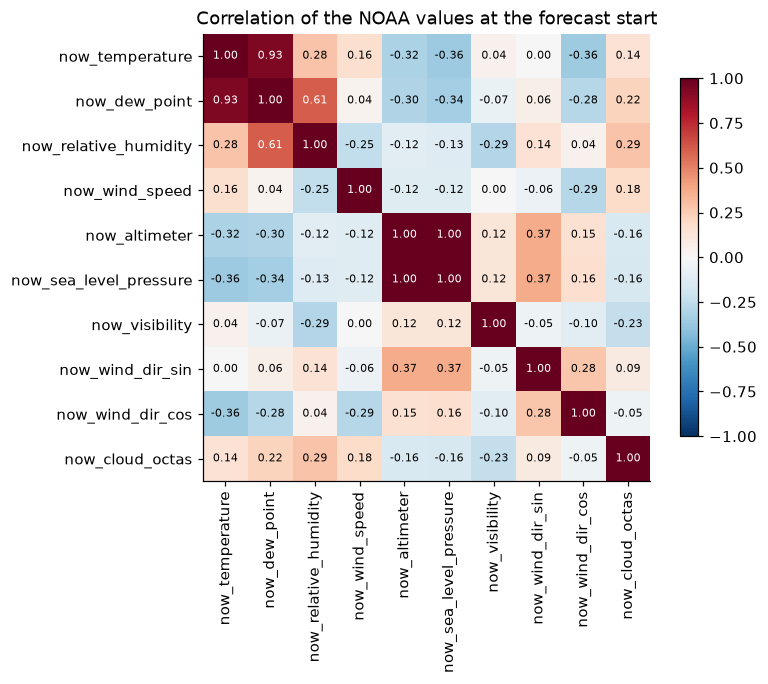

,now_temperature,now_dew_point,now_relative_humidity,now_wind_speed,now_altimeter,now_sea_level_pressure,now_visibility,now_wind_dir_sin,now_wind_dir_cos,now_cloud_octas
VIF,331.3,464.6,70.3,1.3,2174.3,2242.5,1.2,1.4,1.4,1.2


In [5]:
def vif(frame):
    # VIF of each column: 1 / (1 - R^2) of a regression of that column on all the other columns
    frame = frame.dropna()
    out = {}
    for column in frame.columns:
        others = frame.drop(columns=column)
        r2 = LinearRegression().fit(others, frame[column]).score(others, frame[column])
        out[column] = 1 / (1 - r2)
    return pd.Series(out, name="VIF")


corr = at_start.corr()
fig, ax = plt.subplots(figsize=(7.5, 6.2))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
fig.colorbar(image, ax=ax, shrink=0.8)
ax.set_title("Correlation of the NOAA values at the forecast start")
fig.tight_layout()
save_fig(fig, "noaa_correlation")
plt.show()
display(vif(at_start).round(1).to_frame().T)

**What to drop or change:**

- `now_sea_level_pressure` vs `now_altimeter`: correlation 1.00, two versions of the same pressure. Keep the altimeter (never missing).
- `now_relative_humidity` is computed from temperature and dew point, so it is not a separate measurement. Drop it.
- `now_temperature` vs `now_dew_point`: correlation 0.93. Replace the dew point by the **dew point depression** (temperature − dew point, how dry the air is), which carries the same information but is barely correlated with the temperature.

After these changes, every VIF should be close to 1.

In [6]:
samples["now_dewpoint_depression"] = samples["now_temperature"] - samples["now_dew_point"]
at_start["now_dewpoint_depression"] = at_start["now_temperature"] - at_start["now_dew_point"]
NOAA_RAW = ["now_temperature", "now_dewpoint_depression", "now_wind_speed", "now_wind_dir_sin", "now_wind_dir_cos",
            "now_altimeter", "now_visibility", "now_cloud_octas"]
display(vif(at_start[NOAA_RAW]).round(1).to_frame().T)

,now_temperature,now_dewpoint_depression,now_wind_speed,now_wind_dir_sin,now_wind_dir_cos,now_altimeter,now_visibility,now_cloud_octas
VIF,1.4,1.4,1.3,1.4,1.4,1.4,1.2,1.2


### 3.4 A first linear regression

- **y**: the temperature at the target hour, as is.
- **X**: the 8 NOAA values at the forecast start, plus two kinds of calendar inputs for the target hour: the **hour of day** as sin/cos (`hour_sin1`, `hour_cos1`, `hour_sin2`, `hour_cos2`, from `03`) and the **date** as sin/cos of the day of the year (`doy_sin1`, `doy_cos1`, `doy_sin2`, `doy_cos2`, built the same way as in `03`: one turn per year, so Dec 31 and Jan 1 are neighbours): 16 inputs.
- **One model for all 336 hours** of a forecast, plain `LinearRegression`. The few missing inputs are filled with the training mean (`SimpleImputer`, fitted on the training rows only).
- For comparison, the same model **without the date** (12 inputs), to show how much knowing the date matters.
- The table it learns from (identifiers, y and the 16 inputs, one row per forecast hour) is saved to `data/processed/model_samples_lr1_noaa_raw_2024-03-14_to_2026-09-16.csv` for inspection. The few missing inputs are left empty there; the model fills them as above.

Saved data/processed/model_samples_lr1_noaa_raw_2024-03-14_to_2026-09-16.csv: y = temperature, X = 16 inputs, 308,112 rows (54.0 MB)


Fold 1 (2025)                      Fold 2 (2026)                     
                                       MAE  RMSE % vs hist. avg           MAE  RMSE % vs hist. avg
Persistence                           3.87  4.80         -33.61          2.87  3.67         -15.16
Historical average                    2.90  3.51           0.00          2.49  3.06           0.00
LR, raw NOAA values, no date          3.33  4.16         -15.00          2.91  3.53         -16.83
LR, raw NOAA values                   2.98  3.57          -2.98          2.50  3.09          -0.21

MAE by forecast day - Fold 1 (2025)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,2.08,3.13,3.54,3.65,3.75,3.79,3.92,4.22,4.47,4.44,4.41,4.41,4.34,4.21
Historical average,2.69,2.74,2.82,2.89,2.90,2.88,2.84,2.81,2.84,2.95,3.05,3.06,3.08,3.04
"LR, raw NOAA values, no date",1.95,2.46,2.83,2.89,2.87,3.14,3.36,3.42,3.71,3.89,3.96,4.05,4.12,4.12
"LR, raw NOAA values",2.53,2.65,2.76,2.83,2.88,2.95,3.02,3.03,3.10,3.20,3.27,3.25,3.20,3.14


MAE by forecast day - Fold 2 (2026)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,1.99,2.35,2.68,2.99,3.24,2.93,2.82,2.83,2.84,3.09,3.37,3.34,3.17,2.97
Historical average,2.40,2.42,2.45,2.50,2.49,2.43,2.43,2.45,2.46,2.50,2.57,2.64,2.65,2.58
"LR, raw NOAA values, no date",2.38,2.52,2.64,2.92,3.20,3.13,3.13,3.00,2.90,2.98,3.09,3.10,3.06,2.95
"LR, raw NOAA values",2.28,2.33,2.39,2.43,2.49,2.46,2.50,2.50,2.51,2.54,2.60,2.70,2.72,2.70


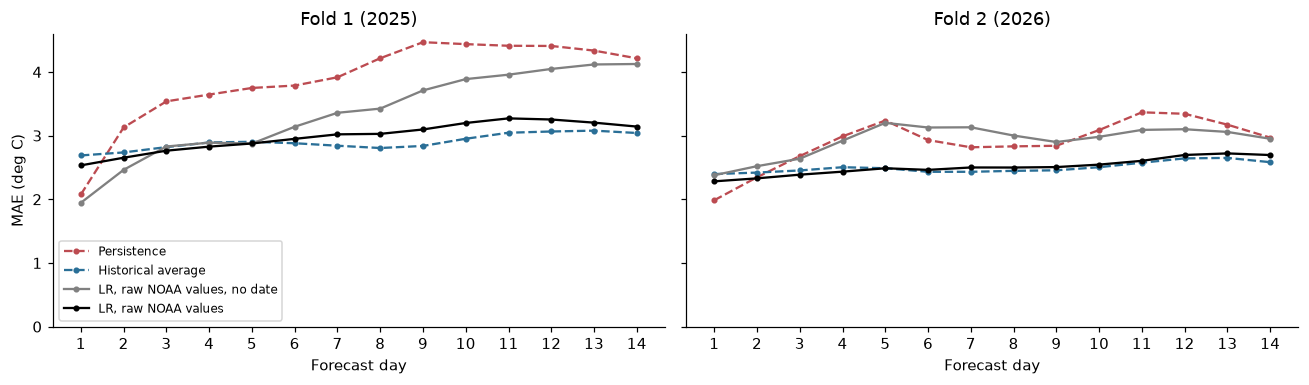

In [7]:
# Date of the target hour: position in the year as sin/cos (same formula as 03)
local_target = samples["target_utc"].dt.tz_convert(NY)
year_fraction = ((local_target.dt.dayofyear - 1 + local_target.dt.hour / 24)
                 / np.where(local_target.dt.is_leap_year, 366, 365))
for k in (1, 2):
    samples[f"doy_sin{k}"] = np.sin(2 * np.pi * k * year_fraction)
    samples[f"doy_cos{k}"] = np.cos(2 * np.pi * k * year_fraction)

HOUR = ["hour_sin1", "hour_cos1", "hour_sin2", "hour_cos2"]
DATE = ["doy_sin1", "doy_cos1", "doy_sin2", "doy_cos2"]
RAW_X = NOAA_RAW + HOUR + DATE  # 16 inputs
NO_DATE_X = NOAA_RAW + HOUR     # the same without the date, for comparison

# Save the step-1 table (identifiers, y and the 16 inputs) so it can be opened and checked
LR1_FILE = PROJECT_ROOT / "data" / "processed" / "model_samples_lr1_noaa_raw_2024-03-14_to_2026-09-16.csv"
samples[["run_day", "target_utc", "target_local", "lead_day", "temperature", *RAW_X]].to_csv(LR1_FILE, index=False,
                                                                                              float_format="%.8g")
print(f"Saved {LR1_FILE.relative_to(PROJECT_ROOT)}: y = temperature, X = {len(RAW_X)} inputs, "
      f"{len(samples):,} rows ({LR1_FILE.stat().st_size / 1024 ** 2:.1f} MB)")


def fit_raw_lr(train, inputs=RAW_X):
    return make_pipeline(SimpleImputer(strategy="mean"), LinearRegression()).fit(train[inputs], train["temperature"])


STEP1 = HEURISTICS | {
    "LR, raw NOAA values, no date": lambda train, valid: fit_raw_lr(train, NO_DATE_X).predict(valid[NO_DATE_X]),
    "LR, raw NOAA values": lambda train, valid: fit_raw_lr(train).predict(valid[RAW_X]),
}
step1_errors = validate(STEP1)
display(summary(step1_errors))

by_day = mae_by_day(step1_errors)
for fold, table in by_day.items():
    print(f"MAE by forecast day - {fold}")
    display(table.round(2))

styles = {"Persistence": ("#bc4b51", "--"), "Historical average": ("#2a6f97", "--"),
          "LR, raw NOAA values, no date": ("grey", "-"), "LR, raw NOAA values": ("black", "-")}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (fold, table) in zip(axes, by_day.items()):
    for method, (color, line) in styles.items():
        ax.plot(table.columns, table.loc[method], color=color, linestyle=line, marker="o", markersize=3, label=method)
    ax.set(title=fold, xlabel="Forecast day")
    ax.set_xticks(range(1, 15))
axes[0].set(ylabel="MAE (deg C)", ylim=(0, None))
axes[0].legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "noaa_raw_lr_mae_by_day")
plt.show()

### 3.5 Residuals

Residual = observed − predicted. A good model leaves residuals that average to 0 in every group; a pattern means something the model does not capture.

1. Predicted against observed (Fold 2).
2. Mean residual by forecast day (both folds).
3. Mean residual by month of the target, on the **training** data of Fold 2 (Mar 2024 – Jul 2026, so every month appears).
4. Mean residual by hour of the target (both folds).

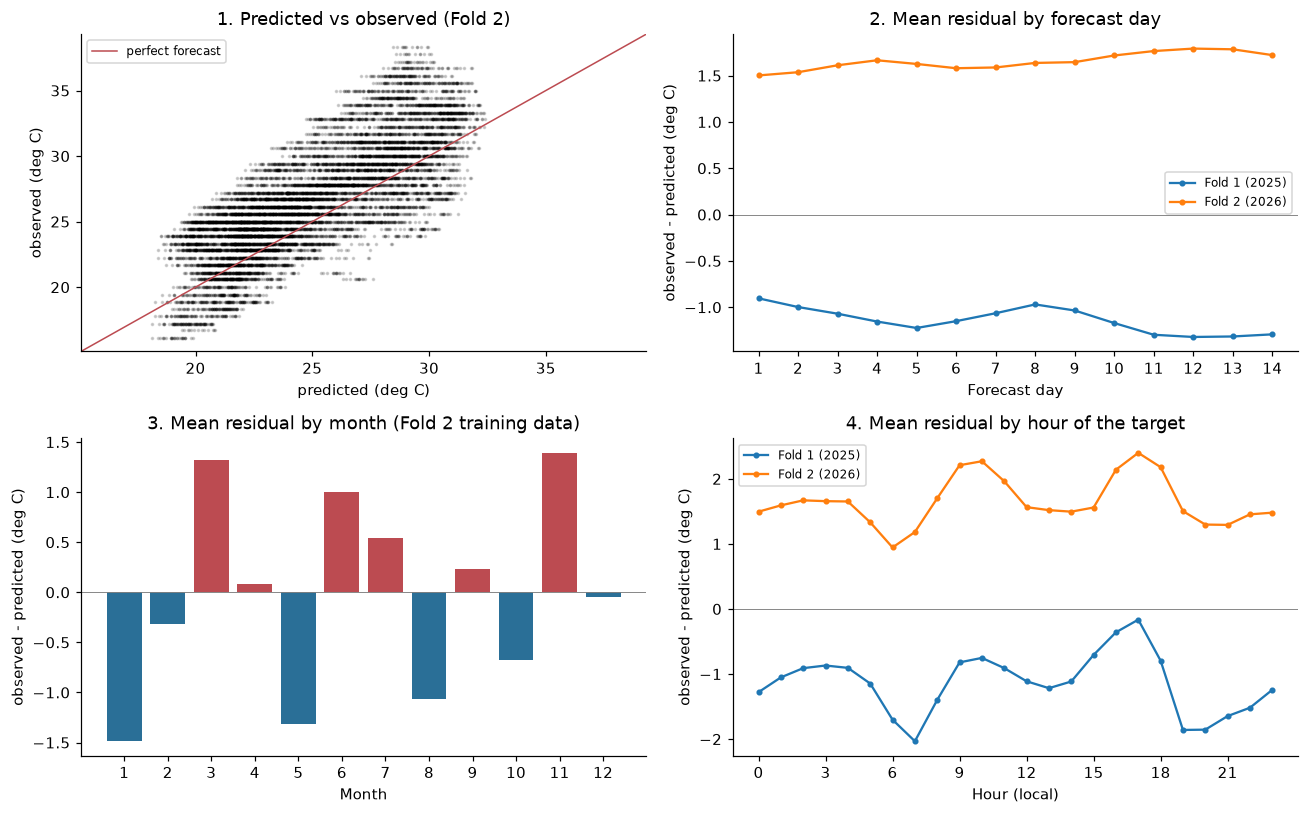

Coefficients of the Fold 2 model (deg C per unit of each input):


,now_temperature,now_dewpoint_depression,now_wind_speed,now_wind_dir_sin,now_wind_dir_cos,now_altimeter,now_visibility,now_cloud_octas,hour_sin1,hour_cos1,hour_sin2,hour_cos2,doy_sin1,doy_cos1,doy_sin2,doy_cos2
coefficient,0.151,0.008,-0.009,-0.022,-0.137,0.077,0.013,-0.059,-3.055,-3.168,0.524,0.786,-1.538,-9.25,-0.127,-0.837


In [8]:
train2, valid2 = split(*FOLDS["Fold 2 (2026)"])
model2 = fit_raw_lr(train2)
predicted2 = pd.Series(model2.predict(valid2[RAW_X]), index=valid2.index)
in_sample = train2["temperature"] - model2.predict(train2[RAW_X])
target_local = lambda rows: rows["target_utc"].dt.tz_convert(NY)

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
ax = axes[0, 0]
ax.scatter(predicted2, valid2["temperature"], s=2, alpha=0.15, color="black")
lims = [valid2["temperature"].min() - 1, valid2["temperature"].max() + 1]
ax.plot(lims, lims, color="#bc4b51", linewidth=1, label="perfect forecast")
ax.set(title="1. Predicted vs observed (Fold 2)", xlabel="predicted (deg C)", ylabel="observed (deg C)", xlim=lims, ylim=lims)
ax.legend(fontsize=8)

ax = axes[0, 1]
for fold, e in step1_errors.items():
    ax.plot(range(1, 15), e.groupby("lead_day")["LR, raw NOAA values"].mean(), marker="o", markersize=3, label=fold)
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="2. Mean residual by forecast day", xlabel="Forecast day", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(1, 15))
ax.legend(fontsize=8)

ax = axes[1, 0]
by_month = in_sample.groupby(target_local(train2).dt.month).mean()
ax.bar(by_month.index, by_month, color=np.where(by_month > 0, "#bc4b51", "#2a6f97"))
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="3. Mean residual by month (Fold 2 training data)", xlabel="Month", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(1, 13))

ax = axes[1, 1]
for fold, e in step1_errors.items():
    _, valid = split(*FOLDS[fold])
    ax.plot(range(24), e["LR, raw NOAA values"].groupby(target_local(valid).dt.hour).mean(), marker="o", markersize=3,
            label=fold)
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="4. Mean residual by hour of the target", xlabel="Hour (local)", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "noaa_raw_lr_residuals")
plt.show()

print("Coefficients of the Fold 2 model (deg C per unit of each input):")
display(pd.Series(model2[-1].coef_, index=RAW_X).round(3).to_frame("coefficient").T)

### 3.6 Polynomial features

The residuals show systematic patterns. Can a more flexible model remove them? `PolynomialFeatures(degree=2)` adds the square of every input and the product of every pair, so the 16 inputs become 152. The inputs are standardised first (`StandardScaler`): their scales differ a lot (pressure ≈ 1,018 hPa, sin/cos between −1 and 1), and squaring would make that worse. Everything else stays the same.

The table compares the **training MAE** (on the rows the model learned from) with the **validation MAE**:

- a model that is too simple (**high bias**) has a high error on both;
- a model that is too flexible (**high variance**) has a much lower training error than validation error.

Fold 1 (2025)                      Fold 2 (2026)                     
                                        MAE  RMSE % vs hist. avg           MAE  RMSE % vs hist. avg
Persistence                            3.87  4.80         -33.61          2.87  3.67         -15.16
Historical average                     2.90  3.51           0.00          2.49  3.06           0.00
LR, raw NOAA values                    2.98  3.57          -2.98          2.50  3.09          -0.21
LR, raw NOAA values + poly(2)          3.04  3.69          -4.96          3.16  3.82         -26.85

inputs  training MAE  validation MAE
Fold 1 (2025) LR, raw NOAA values              16.0          3.39            2.98
              LR, raw NOAA values + poly(2)   152.0          3.23            3.04
Fold 2 (2026) LR, raw NOAA values              16.0          3.69            2.50
              LR, raw NOAA values + poly(2)   152.0          3.55            3.16

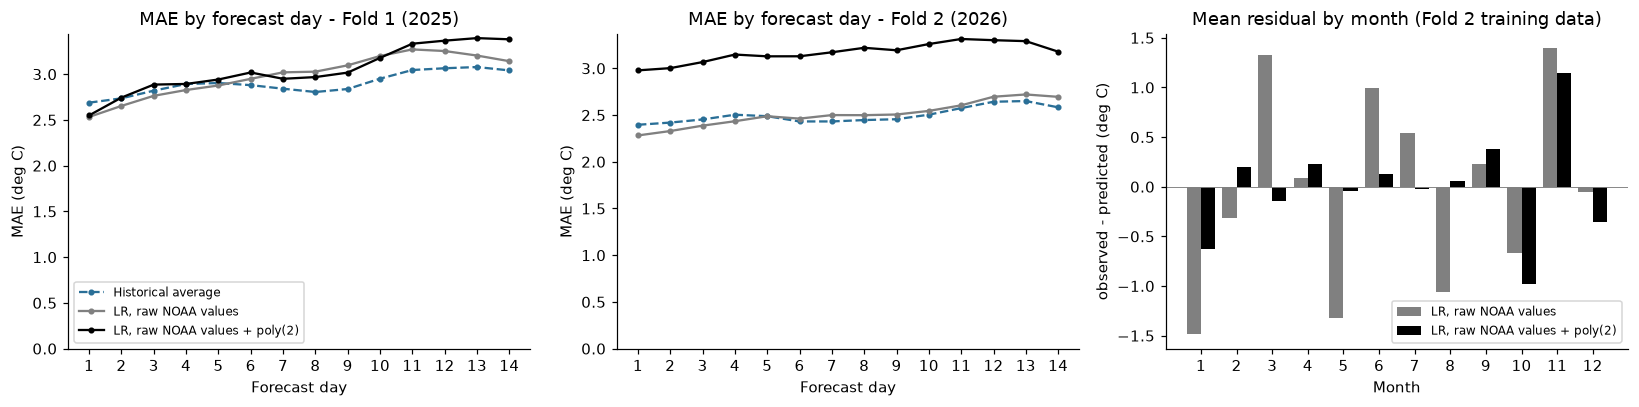

In [9]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


def fit_poly_lr(train):
    return make_pipeline(SimpleImputer(strategy="mean"), StandardScaler(), PolynomialFeatures(degree=2, include_bias=False),
                         LinearRegression()).fit(train[RAW_X], train["temperature"])


RAW_MODELS = {"LR, raw NOAA values": fit_raw_lr, "LR, raw NOAA values + poly(2)": fit_poly_lr}
poly_errors = validate(HEURISTICS | {name: (lambda fit: lambda train, valid: fit(train).predict(valid[RAW_X]))(fit)
                                     for name, fit in RAW_MODELS.items()})
display(summary(poly_errors))

fit_table = {}
for fold, (first, last) in FOLDS.items():
    train, valid = split(first, last)
    for name, fit in RAW_MODELS.items():
        model = fit(train)
        fit_table[(fold, name)] = {
            "inputs": model[-1].n_features_in_,
            "training MAE": mae(train["temperature"] - model.predict(train[RAW_X])),
            "validation MAE": mae(valid["temperature"] - model.predict(valid[RAW_X])),
        }
display(pd.DataFrame(fit_table).T.round(2))

poly2 = fit_poly_lr(train2)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
styles = {"Historical average": ("#2a6f97", "--"), "LR, raw NOAA values": ("grey", "-"),
          "LR, raw NOAA values + poly(2)": ("black", "-")}
for ax, (fold, table) in zip(axes[:2], mae_by_day(poly_errors).items()):
    for method, (color, line) in styles.items():
        ax.plot(table.columns, table.loc[method], color=color, linestyle=line, marker="o", markersize=3, label=method)
    ax.set(title=f"MAE by forecast day - {fold}", xlabel="Forecast day", ylabel="MAE (deg C)", ylim=(0, None))
    ax.set_xticks(range(1, 15))
axes[0].legend(fontsize=8)

month = target_local(train2).dt.month
by_month = pd.DataFrame({
    "LR, raw NOAA values": (train2["temperature"] - model2.predict(train2[RAW_X])).groupby(month).mean(),
    "LR, raw NOAA values + poly(2)": (train2["temperature"] - poly2.predict(train2[RAW_X])).groupby(month).mean(),
})
ax = axes[2]
ax.bar(by_month.index - 0.2, by_month.iloc[:, 0], width=0.4, color="grey", label=by_month.columns[0])
ax.bar(by_month.index + 0.2, by_month.iloc[:, 1], width=0.4, color="black", label=by_month.columns[1])
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="Mean residual by month (Fold 2 training data)", xlabel="Month", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(1, 13))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "noaa_raw_lr_poly")
plt.show()

## 4. Step 2: NOAA only, anomalies

With the date, step 1 knows the season and gets about as good as the historical average, but not better. Its residuals show what is left:

1. One model for all 14 days cannot make use of tonight's weather for the next day or two: even on day 1 it is barely better than the historical average (MAE 2.53 and 2.28, against 2.69 and 2.40).
2. The shape of the day is off around sunrise and sunset (residual plot 4).
3. Each fold keeps a constant offset (residual plot 2): whether these two weeks turn out warmer or colder than normal.

Step 2 changes three things:

- **y**: how much warmer than normal the target hour is, `temperature − hist_avg`. The forecast is `hist_avg` + the predicted difference. The historical average (`03`) is computed from 11 years of observations (2015 on), so it gives the seasonal and the daily cycle more reliably than a model can learn them from the one to two and a half years of forecasts it is trained on. The regression only has to learn the departure from it.
- **X**: how much warmer than normal the station is at the forecast start, `anom_now` (at 11pm) and `anom_24h` (mean of the last 24 hours), both from `03`, plus the 4 hour-of-day terms: 6 inputs. The date is no longer needed: it is already in `hist_avg`.
- **One model per forecast day** (14 models): the weight on today's anomaly can be large on day 1 and fade on later days.

Recent forecasts get more weight (the weight halves every 180 days back), as in the final model. These 6 inputs are exactly the final model's inputs without the ECMWF ones, so the gap between this step and the next one is what ECMWF adds.

Fold 1 (2025)                      Fold 2 (2026)                     
                              MAE  RMSE % vs hist. avg           MAE  RMSE % vs hist. avg
Persistence                  3.87  4.80         -33.61          2.87  3.67         -15.16
Historical average           2.90  3.51           0.00          2.49  3.06           0.00
LR, raw NOAA values          2.98  3.57          -2.98          2.50  3.09          -0.21
LR, NOAA anomalies           3.06  3.73          -5.72          2.28  2.82           8.53

LR, NOAA anomalies: training vs validation error


,training MAE,validation MAE
Fold 1 (2025),3.34,3.06
Fold 2 (2026),3.70,2.28


MAE by forecast day - Fold 1 (2025)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,2.08,3.13,3.54,3.65,3.75,3.79,3.92,4.22,4.47,4.44,4.41,4.41,4.34,4.21
Historical average,2.69,2.74,2.82,2.89,2.90,2.88,2.84,2.81,2.84,2.95,3.05,3.06,3.08,3.04
"LR, raw NOAA values",2.53,2.65,2.76,2.83,2.88,2.95,3.02,3.03,3.10,3.20,3.27,3.25,3.20,3.14
"LR, NOAA anomalies",1.85,2.57,2.94,3.11,3.17,3.16,3.08,3.07,3.12,3.28,3.39,3.39,3.43,3.40


MAE by forecast day - Fold 2 (2026)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,1.99,2.35,2.68,2.99,3.24,2.93,2.82,2.83,2.84,3.09,3.37,3.34,3.17,2.97
Historical average,2.40,2.42,2.45,2.50,2.49,2.43,2.43,2.45,2.46,2.50,2.57,2.64,2.65,2.58
"LR, raw NOAA values",2.28,2.33,2.39,2.43,2.49,2.46,2.50,2.50,2.51,2.54,2.60,2.70,2.72,2.70
"LR, NOAA anomalies",1.62,2.03,2.21,2.34,2.36,2.30,2.29,2.31,2.33,2.39,2.48,2.52,2.53,2.48


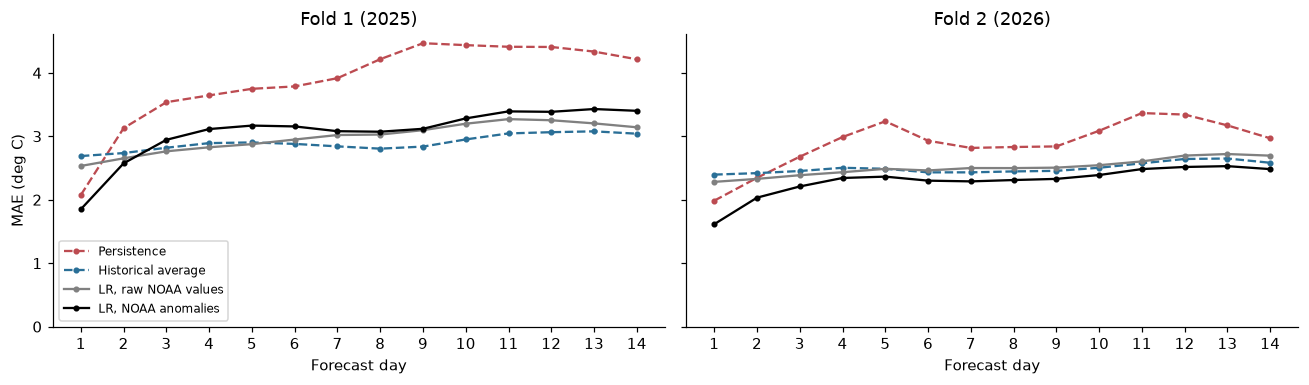

In [10]:
HALF_LIFE_DAYS = 180  # weight of a training run halves every 180 days before the newest run
NOAA_ANOMALY = ["anom_now", "anom_24h", "hour_sin1", "hour_cos1", "hour_sin2", "hour_cos2"]


def fit_by_day(train, features, base="hist_avg"):
    # One LinearRegression per forecast day: (temperature - base) ~ features, recent runs weighted more.
    # base=None fits the temperature itself (used once, in 5.3).
    newest = train["run_day"].max()
    models = {}
    for day in range(1, 15):
        rows = train[train["lead_day"].eq(day)].dropna(subset=["temperature", "hist_avg", *features])
        weight = 0.5 ** ((newest - rows["run_day"]).dt.days / HALF_LIFE_DAYS)
        target = rows["temperature"] - (rows[base] if base else 0)
        models[day] = LinearRegression().fit(rows[features], target, sample_weight=weight)
    return models


def predict_by_day(models, rows, base="hist_avg"):
    # base (hist_avg) + the predicted difference, with the model of each row's forecast day
    prediction = np.full(len(rows), np.nan)
    for day, model in models.items():
        features = list(model.feature_names_in_)
        ok = (rows["lead_day"].eq(day) & rows[features].notna().all(axis=1)).to_numpy()
        start = rows[base].to_numpy()[ok] if base else 0
        prediction[ok] = start + model.predict(rows.loc[ok, features])
    return prediction


STEP2 = HEURISTICS | {
    "LR, raw NOAA values": lambda train, valid: fit_raw_lr(train).predict(valid[RAW_X]),
    "LR, NOAA anomalies": lambda train, valid: predict_by_day(fit_by_day(train, NOAA_ANOMALY), valid),
}
step2_errors = validate(STEP2)
display(summary(step2_errors))

fit_table = {}
for fold, (first, last) in FOLDS.items():
    train, valid = split(first, last)
    models = fit_by_day(train, NOAA_ANOMALY)
    fit_table[fold] = {"training MAE": mae(train["temperature"] - predict_by_day(models, train)),
                       "validation MAE": mae(valid["temperature"] - predict_by_day(models, valid))}
print("LR, NOAA anomalies: training vs validation error")
display(pd.DataFrame(fit_table).T.round(2))

by_day = mae_by_day(step2_errors)
for fold, table in by_day.items():
    print(f"MAE by forecast day - {fold}")
    display(table.round(2))

styles = {"Persistence": ("#bc4b51", "--"), "Historical average": ("#2a6f97", "--"),
          "LR, raw NOAA values": ("grey", "-"), "LR, NOAA anomalies": ("black", "-")}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (fold, table) in zip(axes, by_day.items()):
    for method, (color, line) in styles.items():
        ax.plot(table.columns, table.loc[method], color=color, linestyle=line, marker="o", markersize=3, label=method)
    ax.set(title=fold, xlabel="Forecast day")
    ax.set_xticks(range(1, 15))
axes[0].set(ylabel="MAE (deg C)", ylim=(0, None))
axes[0].legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "noaa_anomaly_lr_mae_by_day")
plt.show()

### 4.1 Residuals and what the model learned

The same residual checks as in step 1 (grey: step 1, black: step 2), and the weight each forecast day's model puts on today's anomaly.

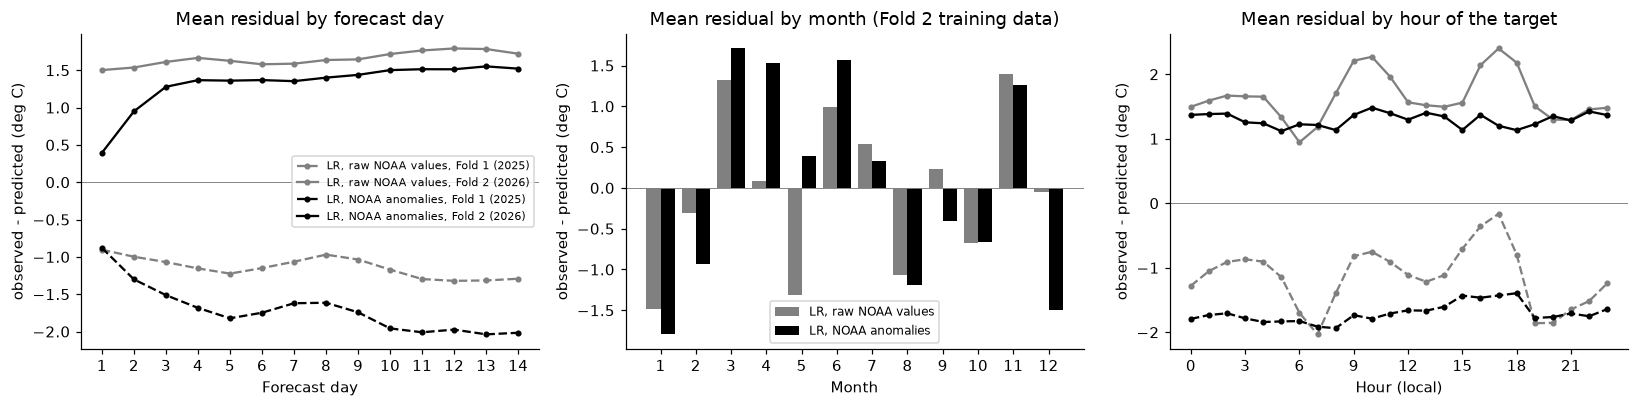

Weight on today's anomaly by forecast day (Fold 2 models): 1 = carried over in full, 0 = forgotten


forecast day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
anom_now,0.81,0.33,0.01,-0.03,0.05,-0.08,-0.02,0.07,-0.04,-0.14,-0.08,0.11,0.08,-0.00
anom_24h,-0.05,0.07,0.24,0.24,0.11,0.21,0.16,0.02,0.08,0.20,0.18,-0.01,-0.00,0.06
anom_now + anom_24h,0.76,0.40,0.25,0.22,0.17,0.14,0.13,0.09,0.05,0.06,0.10,0.10,0.07,0.05


In [11]:
anomaly2 = fit_by_day(train2, NOAA_ANOMALY)
residual = {"LR, raw NOAA values": (train2["temperature"] - model2.predict(train2[RAW_X]),
                                    {f: e["LR, raw NOAA values"] for f, e in step2_errors.items()}),
            "LR, NOAA anomalies": (train2["temperature"] - predict_by_day(anomaly2, train2),
                                   {f: e["LR, NOAA anomalies"] for f, e in step2_errors.items()})}
colors = {"LR, raw NOAA values": "grey", "LR, NOAA anomalies": "black"}
fold_lines = {"Fold 1 (2025)": "--", "Fold 2 (2026)": "-"}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
ax = axes[0]
for name, (_, by_fold) in residual.items():
    for fold, e in by_fold.items():
        ax.plot(range(1, 15), e.groupby(step2_errors[fold]["lead_day"]).mean(), color=colors[name],
                linestyle=fold_lines[fold], marker="o", markersize=3, label=f"{name}, {fold}")
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="Mean residual by forecast day", xlabel="Forecast day", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(1, 15))
ax.legend(fontsize=7)

ax = axes[1]
month = target_local(train2).dt.month
for shift, (name, (in_sample, _)) in zip((-0.2, 0.2), residual.items()):
    by_month = in_sample.groupby(month).mean()
    ax.bar(by_month.index + shift, by_month, width=0.4, color=colors[name], label=name)
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="Mean residual by month (Fold 2 training data)", xlabel="Month", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(1, 13))
ax.legend(fontsize=8)

ax = axes[2]
for name, (_, by_fold) in residual.items():
    for fold, e in by_fold.items():
        _, valid = split(*FOLDS[fold])
        ax.plot(range(24), e.groupby(target_local(valid).dt.hour).mean(), color=colors[name],
                linestyle=fold_lines[fold], marker="o", markersize=3)
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="Mean residual by hour of the target", xlabel="Hour (local)", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(0, 24, 3))
fig.tight_layout()
save_fig(fig, "noaa_anomaly_lr_residuals")
plt.show()

weights = pd.DataFrame({day: model.coef_ for day, model in anomaly2.items()}, index=NOAA_ANOMALY).loc[["anom_now", "anom_24h"]]
weights.loc["anom_now + anom_24h"] = weights.sum()
weights.columns.name = "forecast day"
print("Weight on today's anomaly by forecast day (Fold 2 models): 1 = carried over in full, 0 = forgotten")
display(weights.round(2))

### 4.2 The offset that remains

From forecast day 3 on, the residuals of step 2 stay at an almost constant offset, with opposite signs in the two folds. A per-day model's intercept is the average departure from normal it saw in training (recent forecasts weighted more). The table compares it with the average departure from normal that actually happened in each fold.

In [12]:
offset = {}
for fold, (first, last) in FOLDS.items():
    train, valid = split(first, last)
    weight = 0.5 ** ((train["run_day"].max() - train["run_day"]).dt.days / HALF_LIFE_DAYS)
    offset[fold] = {
        "mean departure from normal in training (weighted)": np.average(train["temperature"] - train["hist_avg"], weights=weight),
        "mean intercept of the 14 models": np.mean([m.intercept_ for m in fit_by_day(train, NOAA_ANOMALY).values()]),
        "mean departure from normal in the fold": (valid["temperature"] - valid["hist_avg"]).mean(),
    }
display(pd.DataFrame(offset).round(2))

,Fold 1 (2025),Fold 2 (2026)
mean departure from normal in training (weighted),0.93,0.22
mean intercept of the 14 models,0.81,0.17
mean departure from normal in the fold,-0.97,1.76


### 4.3 Step 2 in short

- Predicting the departure from the historical average removes the hour-of-day pattern of step 1, and one model per forecast day makes the first two days much better (day 1 MAE 1.85 and 1.62, against 2.53 and 2.28 in step 1).
- Today's anomaly is only remembered for about two days: its weight falls from about 0.8 on day 1 to about 0.25 on day 3, and is 0.1 or less from day 8.
- After that, the forecast is the historical average plus the average departure seen in training. Whether the next two weeks will be warmer or colder than normal cannot be read from the station's own measurements at 11pm, so on Fold 1 the model is still worse than the historical average. Over all 14 days, step 2 beats step 1 on Fold 2 (2.28 against 2.50) but not on Fold 1 (3.06 against 2.98): both NOAA-only steps end up about as good as the historical average.

The missing information has to come from a forecast of the weather to come: the ECMWF model (step 3).

## 5. Step 3: adding the ECMWF forecasts

ECMWF's model simulates the whole atmosphere, so it can see weather systems that are still hundreds of kilometres away. Its runs from before the forecast start (`03`) are used in three ways below:

1. as forecasts on their own, with no regression (5.1);
2. as inputs of the linear regression, together with the NOAA inputs of step 2 (5.2);
3. one group of inputs at a time, to see what each adds (5.3).

### 5.1 The forecasts as they are

- **ECMWF raw**: the 12z run of the run day, as published.
- **ECMWF lagged mean**: the mean of the 12z and 00z runs of the run day and the 12z run of the day before.
- **GFS raw**: the same for GFS, the US weather service's model. Its archive starts in Apr 2026, so it can only be compared on Fold 2.

Fold 1 (2025)                      Fold 2 (2026)                     
                             MAE  RMSE % vs hist. avg           MAE  RMSE % vs hist. avg
Persistence                 3.87  4.80         -33.61          2.87  3.67         -15.16
Historical average          2.90  3.51           0.00          2.49  3.06           0.00
LR, NOAA anomalies          3.06  3.73          -5.72          2.28  2.82           8.53
ECMWF raw                   2.44  3.30          15.89          2.02  2.80          19.04
ECMWF lagged mean           2.29  3.05          21.05          1.88  2.57          24.51

Fold 2, hours that also have a GFS forecast: 12,918 of 12,966


,Historical average,ECMWF raw,GFS raw
MAE,2.50,2.02,2.60
RMSE,3.07,2.80,3.51


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Historical average,2.44,2.44,2.45,2.50,2.49,2.43,2.43,2.45,2.46,2.50,2.57,2.64,2.65,2.58
ECMWF raw,1.25,1.27,1.29,1.31,1.38,1.76,1.80,2.04,2.20,2.37,2.70,3.06,3.50,3.48
GFS raw,1.19,1.65,1.76,1.97,2.05,2.44,2.50,2.57,2.81,3.34,3.89,3.69,3.86,4.05


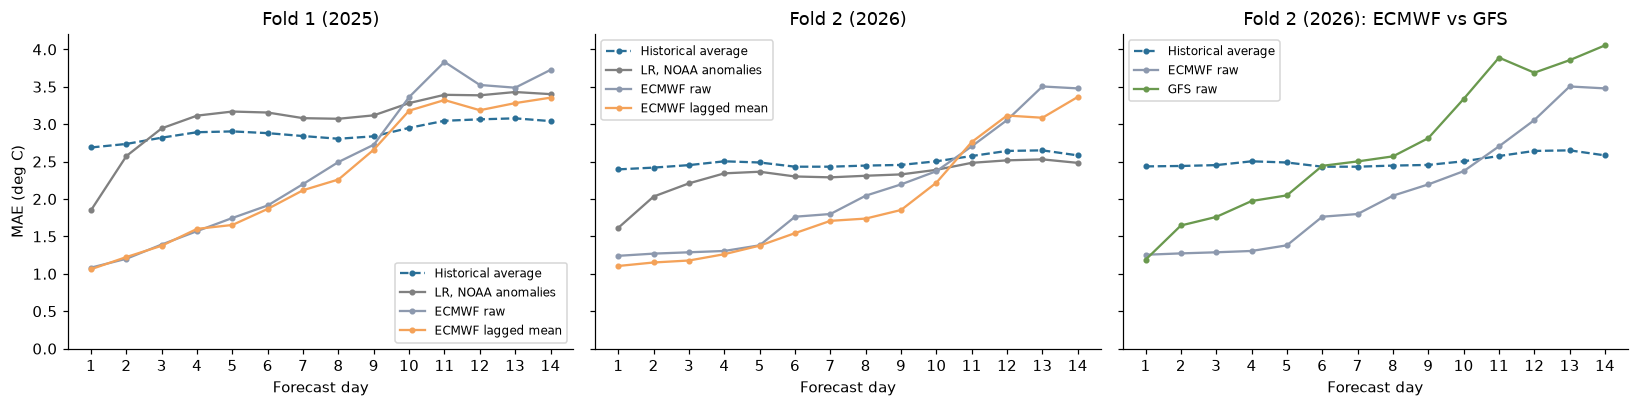

In [13]:
RAW_FORECASTS = {"ECMWF raw": lambda train, valid: valid["ecmwf_12z"],
                 "ECMWF lagged mean": lambda train, valid: valid["ecmwf_lagged_mean"]}
STEP2_LR = {"LR, NOAA anomalies": STEP2["LR, NOAA anomalies"]}
raw_errors = validate(HEURISTICS | STEP2_LR | RAW_FORECASTS)
display(summary(raw_errors))

# GFS against ECMWF: Fold 2, on the hours where GFS also has a forecast
with_gfs = valid2[valid2["gfs_12z"].notna()]
gfs_errors = pd.DataFrame({"Historical average": with_gfs["hist_avg"], "ECMWF raw": with_gfs["ecmwf_12z"],
                           "GFS raw": with_gfs["gfs_12z"]}).rsub(with_gfs["temperature"], axis=0)
print(f"Fold 2, hours that also have a GFS forecast: {len(with_gfs):,} of {len(valid2):,}")
display(pd.DataFrame({"MAE": mae(gfs_errors), "RMSE": rmse(gfs_errors)}).T.round(2))
gfs_by_day = gfs_errors.groupby(with_gfs["lead_day"]).apply(mae).T
display(gfs_by_day.round(2))

styles = {"Historical average": ("#2a6f97", "--"), "LR, NOAA anomalies": ("grey", "-"),
          "ECMWF raw": ("#8d99ae", "-"), "ECMWF lagged mean": ("#f4a259", "-"), "GFS raw": ("#6a994e", "-")}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, (fold, table) in zip(axes[:2], mae_by_day(raw_errors).items()):
    for method in ["Historical average", "LR, NOAA anomalies", "ECMWF raw", "ECMWF lagged mean"]:
        color, line = styles[method]
        ax.plot(table.columns, table.loc[method], color=color, linestyle=line, marker="o", markersize=3, label=method)
    ax.set(title=fold, xlabel="Forecast day")
for method in ["Historical average", "ECMWF raw", "GFS raw"]:
    color, line = styles[method]
    axes[2].plot(gfs_by_day.columns, gfs_by_day.loc[method], color=color, linestyle=line, marker="o", markersize=3,
                 label=method)
axes[2].set(title="Fold 2 (2026): ECMWF vs GFS", xlabel="Forecast day")
for ax in axes:
    ax.set_xticks(range(1, 15))
    ax.legend(fontsize=8)
axes[0].set(ylabel="MAE (deg C)", ylim=(0, None))
fig.tight_layout()
save_fig(fig, "ecmwf_gfs_raw_mae_by_day")
plt.show()

### 5.2 Linear regression with NOAA and ECMWF

The 6 inputs of step 2, plus 6 built from ECMWF (`03`). Everything else is the same as in step 2: y = `temperature − hist_avg`, one model per forecast day, recent forecasts weighted more.

| Input | Meaning | Built from |
|---|---|---|
| `nwp_lagged_anomaly` | how much warmer than normal the ECMWF lagged mean is | ECMWF − `hist_avg` |
| `nwp_anomaly` | how much warmer than normal the latest (12z) run is | ECMWF − `hist_avg` |
| `nwp_recent_error` | how wrong the 12z run already was over the last 6 observed hours (6–11pm) | NOAA − ECMWF |
| `nwp_bias_14d`, `nwp_bias_30d`, `nwp_bias_60d` | ECMWF's average error over the previous 14 / 30 / 60 days | NOAA − ECMWF |
| `anom_now`, `anom_24h` | how much warmer than normal the station is at the forecast start | NOAA (step 2) |
| `hour_sin1`, `hour_cos1`, `hour_sin2`, `hour_cos2` | hour of the target | calendar (step 2) |

The raw ECMWF temperatures are not inputs themselves: like the target, they enter as a departure from the historical average, so the regression does not have to learn the seasonal cycle again.

**This is the final model** (the same 12 inputs and settings as the model frozen on Oct 4).

Fold 1 (2025)                      Fold 2 (2026)                     
                                   MAE  RMSE % vs hist. avg           MAE  RMSE % vs hist. avg
Persistence                       3.87  4.80         -33.61          2.87  3.67         -15.16
Historical average                2.90  3.51           0.00          2.49  3.06           0.00
LR, NOAA anomalies                3.06  3.73          -5.72          2.28  2.82           8.53
ECMWF raw                         2.44  3.30          15.89          2.02  2.80          19.04
ECMWF lagged mean                 2.29  3.05          21.05          1.88  2.57          24.51
LR, NOAA + ECMWF (final)          2.20  2.87          23.92          1.78  2.37          28.68

LR, NOAA + ECMWF: training vs validation error


,training MAE,validation MAE
Fold 1 (2025),2.28,2.20
Fold 2 (2026),2.50,1.78


MAE by forecast day - Fold 1 (2025)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,2.08,3.13,3.54,3.65,3.75,3.79,3.92,4.22,4.47,4.44,4.41,4.41,4.34,4.21
Historical average,2.69,2.74,2.82,2.89,2.90,2.88,2.84,2.81,2.84,2.95,3.05,3.06,3.08,3.04
"LR, NOAA anomalies",1.85,2.57,2.94,3.11,3.17,3.16,3.08,3.07,3.12,3.28,3.39,3.39,3.43,3.40
ECMWF raw,1.08,1.20,1.39,1.57,1.75,1.91,2.20,2.49,2.73,3.36,3.83,3.52,3.49,3.73
ECMWF lagged mean,1.06,1.22,1.38,1.60,1.65,1.87,2.12,2.26,2.66,3.18,3.32,3.19,3.28,3.35
"LR, NOAA + ECMWF (final)",1.06,1.25,1.43,1.69,1.75,1.89,2.16,2.31,2.52,3.04,3.12,2.88,2.88,3.00


MAE by forecast day - Fold 2 (2026)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,1.99,2.35,2.68,2.99,3.24,2.93,2.82,2.83,2.84,3.09,3.37,3.34,3.17,2.97
Historical average,2.40,2.42,2.45,2.50,2.49,2.43,2.43,2.45,2.46,2.50,2.57,2.64,2.65,2.58
"LR, NOAA anomalies",1.62,2.03,2.21,2.34,2.36,2.30,2.29,2.31,2.33,2.39,2.48,2.52,2.53,2.48
ECMWF raw,1.24,1.27,1.29,1.31,1.38,1.76,1.80,2.04,2.20,2.37,2.70,3.06,3.50,3.48
ECMWF lagged mean,1.10,1.15,1.18,1.26,1.38,1.54,1.71,1.74,1.85,2.22,2.76,3.12,3.09,3.36
"LR, NOAA + ECMWF (final)",1.09,1.17,1.20,1.24,1.35,1.52,1.62,1.75,1.95,2.16,2.51,2.65,2.73,2.86


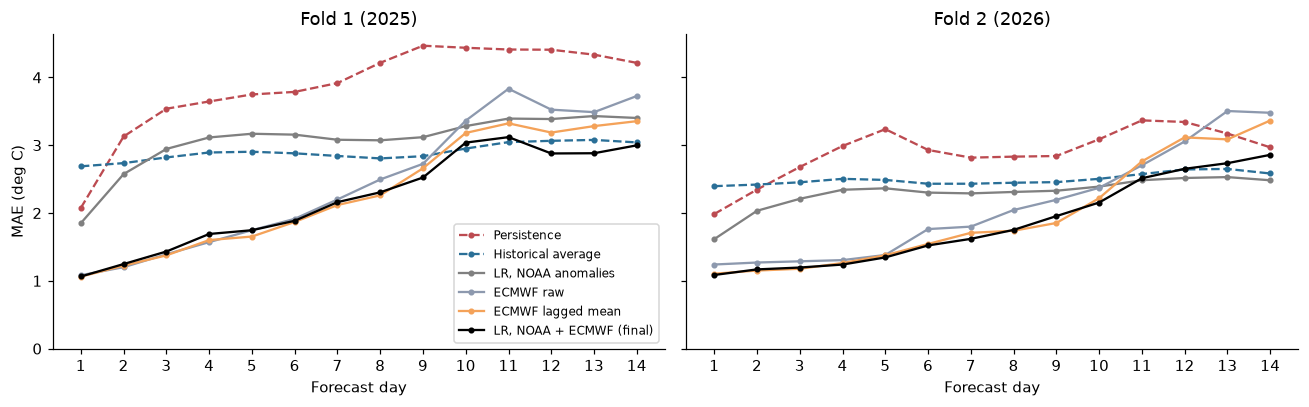

In [14]:
ECMWF_INPUTS = ["nwp_lagged_anomaly", "nwp_anomaly", "nwp_recent_error", "nwp_bias_14d", "nwp_bias_30d", "nwp_bias_60d"]
FINAL_FEATURES = ECMWF_INPUTS + NOAA_ANOMALY
assert FINAL_FEATURES == M14_FEATURES  # the final model's inputs, in the same order

FINAL_LR = {"LR, NOAA + ECMWF (final)": lambda train, valid: predict_by_day(fit_by_day(train, FINAL_FEATURES), valid)}
step3_errors = validate(HEURISTICS | STEP2_LR | RAW_FORECASTS | FINAL_LR)
display(summary(step3_errors))

fit_table = {}
for fold, (first, last) in FOLDS.items():
    train, valid = split(first, last)
    models = fit_by_day(train, FINAL_FEATURES)
    fit_table[fold] = {"training MAE": mae(train["temperature"] - predict_by_day(models, train)),
                       "validation MAE": mae(valid["temperature"] - predict_by_day(models, valid))}
print("LR, NOAA + ECMWF: training vs validation error")
display(pd.DataFrame(fit_table).T.round(2))

by_day = mae_by_day(step3_errors)
for fold, table in by_day.items():
    print(f"MAE by forecast day - {fold}")
    display(table.round(2))

styles["Persistence"] = ("#bc4b51", "--")
styles["LR, NOAA + ECMWF (final)"] = ("black", "-")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (fold, table) in zip(axes, by_day.items()):
    for method in ["Persistence", "Historical average", "LR, NOAA anomalies", "ECMWF raw", "ECMWF lagged mean",
                   "LR, NOAA + ECMWF (final)"]:
        color, line = styles[method]
        ax.plot(table.columns, table.loc[method], color=color, linestyle=line, marker="o", markersize=3, label=method)
    ax.set(title=fold, xlabel="Forecast day")
    ax.set_xticks(range(1, 15))
axes[0].set(ylabel="MAE (deg C)", ylim=(0, None))
axes[0].legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "final_lr_mae_by_day")
plt.show()

### 5.3 What each group of ECMWF inputs adds

Starting from step 2, the ECMWF inputs are added one group at a time; each line keeps the inputs of the lines above.

The last line checks the choice of y once more, now with ECMWF: the same information, but the model predicts the **temperature itself** (y = `temperature`, as in step 1), with ECMWF's forecast temperatures as inputs (`ecmwf_lagged_mean`, `ecmwf_12z`) instead of their departure from the historical average.

Fold 1 (2025)                      Fold 2 (2026)                      Both folds
                                                      MAE  RMSE % vs hist. avg           MAE  RMSE % vs hist. avg        MAE
Persistence                                          3.87  4.80         -33.61          2.87  3.67         -15.16       3.45
Historical average                                   2.90  3.51           0.00          2.49  3.06           0.00       2.73
step 2: NOAA anomalies + hour (6)                    3.06  3.73          -5.72          2.28  2.82           8.53       2.74
+ what ECMWF forecasts (8)                           2.67  3.37           7.79          1.69  2.25          32.15       2.26
+ how wrong it was this evening (9)                  2.43  3.10          16.20          1.70  2.26          31.96       2.12
+ its average error over 14/30/60 days (12)          2.20  2.87          23.92          1.78  2.37          28.68       2.03
same information, y = temperature (12)               2.27  2.99          21.82          1.90  2.58          23.59       2.11

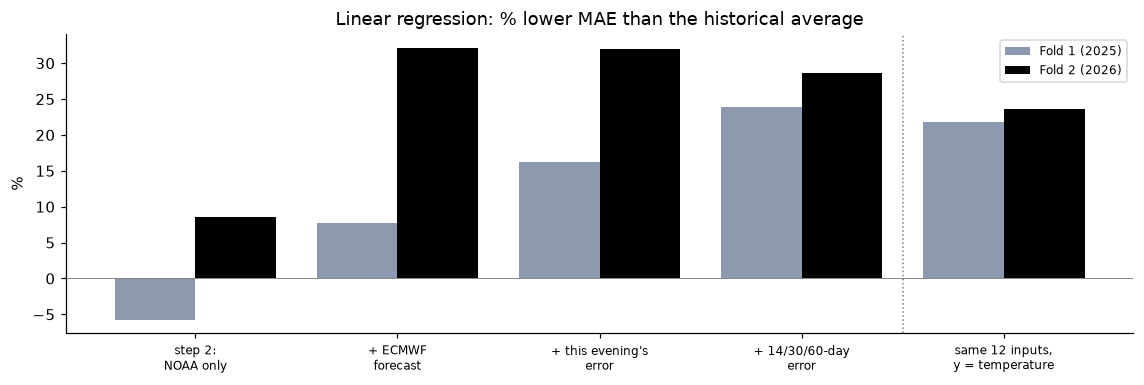

In [15]:
GROUPS = {
    "step 2: NOAA anomalies + hour (6)": NOAA_ANOMALY,
    "+ what ECMWF forecasts (8)": NOAA_ANOMALY + ["nwp_lagged_anomaly", "nwp_anomaly"],
    "+ how wrong it was this evening (9)": NOAA_ANOMALY + ["nwp_lagged_anomaly", "nwp_anomaly", "nwp_recent_error"],
    "+ its average error over 14/30/60 days (12)": FINAL_FEATURES,
}
TEMPERATURE_INPUTS = ["ecmwf_lagged_mean", "ecmwf_12z", "nwp_recent_error", "nwp_bias_14d", "nwp_bias_30d", "nwp_bias_60d",
                      "anom_now", "anom_24h", "hour_sin1", "hour_cos1", "hour_sin2", "hour_cos2"]
RAW_TARGET = "same information, y = temperature (12)"
group_errors = validate(HEURISTICS | {name: (lambda features: lambda train, valid: predict_by_day(fit_by_day(train, features), valid))(features)
                                      for name, features in GROUPS.items()}
                        | {RAW_TARGET: lambda train, valid: predict_by_day(fit_by_day(train, TEMPERATURE_INPUTS, base=None),
                                                                           valid, base=None)})
group_table = summary(group_errors)
group_table[("Both folds", "MAE")] = pd.concat(group_errors.values()).drop(columns="lead_day").pipe(mae).round(2)
display(group_table)

gain = group_table.xs("% vs hist. avg", axis=1, level=1).loc[[*GROUPS, RAW_TARGET]]
fig, ax = plt.subplots(figsize=(10.5, 3.6))
x = np.arange(len(gain))
for shift, (fold, color) in zip((-0.2, 0.2), zip(gain.columns, ("#8d99ae", "black"))):
    ax.bar(x + shift, gain[fold], width=0.4, color=color, label=fold)
ax.axhline(0, color="grey", linewidth=0.6)
ax.axvline(len(GROUPS) - 0.5, color="grey", linestyle=":", linewidth=1)
ax.set_xticks(x, ["step 2:\nNOAA only", "+ ECMWF\nforecast", "+ this evening's\nerror", "+ 14/30/60-day\nerror",
                  "same 12 inputs,\ny = temperature"], fontsize=8)
ax.set(title="Linear regression: % lower MAE than the historical average", ylabel="%")
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "ecmwf_inputs_step_by_step")
plt.show()

### 5.4 Residuals and what the final model learned

The same residual checks as before (grey: step 2, black: final model), the average residual in each fold, and the weight each forecast day's model puts on ECMWF (the two ECMWF anomaly coefficients added up) and on today's anomaly at the station.

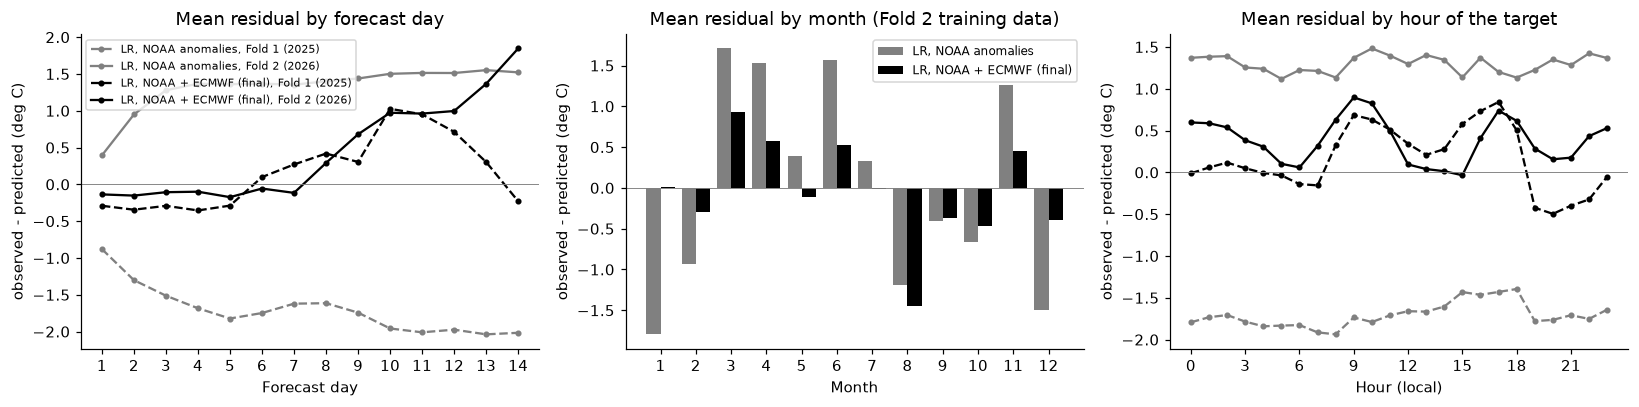

Average residual (observed - predicted) in each fold:


,"LR, NOAA anomalies","LR, NOAA + ECMWF (final)"
Fold 1 (2025),-1.7,0.16
Fold 2 (2026),1.3,0.38


What the Fold 2 models learned: 1 = followed in full, 0 = ignored


forecast day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
weight on ECMWF's forecast,0.95,1.01,0.98,0.95,0.93,0.88,0.83,0.81,0.76,0.67,0.58,0.49,0.38,0.23
weight on today's station anomaly,0.04,-0.06,-0.07,-0.05,-0.09,-0.10,-0.06,-0.07,-0.08,-0.03,0.04,0.09,0.07,0.04


In [16]:
final2 = fit_by_day(train2, FINAL_FEATURES)
residual = {"LR, NOAA anomalies": (train2["temperature"] - predict_by_day(anomaly2, train2),
                                   {f: e["LR, NOAA anomalies"] for f, e in step3_errors.items()}),
            "LR, NOAA + ECMWF (final)": (train2["temperature"] - predict_by_day(final2, train2),
                                         {f: e["LR, NOAA + ECMWF (final)"] for f, e in step3_errors.items()})}
colors = {"LR, NOAA anomalies": "grey", "LR, NOAA + ECMWF (final)": "black"}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
ax = axes[0]
for name, (_, by_fold) in residual.items():
    for fold, e in by_fold.items():
        ax.plot(range(1, 15), e.groupby(step3_errors[fold]["lead_day"]).mean(), color=colors[name],
                linestyle=fold_lines[fold], marker="o", markersize=3, label=f"{name}, {fold}")
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="Mean residual by forecast day", xlabel="Forecast day", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(1, 15))
ax.legend(fontsize=7)

ax = axes[1]
month = target_local(train2).dt.month
for shift, (name, (in_sample, _)) in zip((-0.2, 0.2), residual.items()):
    by_month = in_sample.groupby(month).mean()
    ax.bar(by_month.index + shift, by_month, width=0.4, color=colors[name], label=name)
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="Mean residual by month (Fold 2 training data)", xlabel="Month", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(1, 13))
ax.legend(fontsize=8)

ax = axes[2]
for name, (_, by_fold) in residual.items():
    for fold, e in by_fold.items():
        _, valid = split(*FOLDS[fold])
        ax.plot(range(24), e.groupby(target_local(valid).dt.hour).mean(), color=colors[name],
                linestyle=fold_lines[fold], marker="o", markersize=3)
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="Mean residual by hour of the target", xlabel="Hour (local)", ylabel="observed - predicted (deg C)")
ax.set_xticks(range(0, 24, 3))
fig.tight_layout()
save_fig(fig, "final_lr_residuals")
plt.show()

print("Average residual (observed - predicted) in each fold:")
display(pd.DataFrame({name: {fold: e.mean() for fold, e in by_fold.items()} for name, (_, by_fold) in residual.items()}).round(2))

coefficients = pd.DataFrame({day: model.coef_ for day, model in final2.items()}, index=FINAL_FEATURES)
weights = pd.DataFrame({
    "weight on ECMWF's forecast": coefficients.loc[["nwp_lagged_anomaly", "nwp_anomaly"]].sum(),
    "weight on today's station anomaly": coefficients.loc[["anom_now", "anom_24h"]].sum(),
}).T
weights.columns.name = "forecast day"
print("What the Fold 2 models learned: 1 = followed in full, 0 = ignored")
display(weights.round(2))

### 5.5 Step 3 in short

- **ECMWF on its own** already beats the historical average by 16% (Fold 1) and 19% (Fold 2), and the mean of its last three runs by 21% and 25%, far more than anything built from the station's data (step 1: −3% and −0.2%; step 2: −6% and +9%).
- **GFS** is clearly worse than ECMWF from forecast day 2 on (Fold 2 MAE 2.60 against 2.02), so ECMWF is the forecast to build on.
- **The linear regression with NOAA and ECMWF** beats the historical average by 24% and 29%, and the ECMWF lagged mean in both folds. Its training and validation errors are close, so it does not overfit.
- **Each group of inputs**: on Fold 2, ECMWF's forecast brings most of the gain. On Fold 1, the inputs about ECMWF's recent error bring most of it: that fold starts just after the July 2025 step in the station's readings (`02`, 5.4), when the training data still said that ECMWF reads about 1.3 °C too cold at RDU. The recent error and the 14/30/60-day errors tell the model what the error is now. On Fold 2 they cost a little (32% → 29%); over both folds together, the full set of 12 inputs has the lowest MAE, which is why the final model keeps them all.
- **The choice of y, with ECMWF**: predicting the temperature itself from the same information gives 22% and 24% (both folds 2.11 against 2.03), so predicting the departure from the historical average is still the better choice.
- **What the model learned**: follow ECMWF almost fully for the first 4 days (weight ≈ 1), then less and less (0.23 on day 14), falling back to the historical average where ECMWF is no longer reliable. Today's anomaly at the station gets almost no weight, because ECMWF's forecast already starts from the current weather.
- **Residuals**: the offset left by step 2 is gone (average residual −1.7 and +1.3 → +0.16 and +0.38). What remains is a small pattern by hour of day and an underestimate on the last forecast days.

## 6. Extra check: six 2026 windows

Six forecasts set up exactly like the real task: issued at 11pm, covering the 14 days from 12am. Every model is re-trained for each window on the rows whose target is before that window. This check was run after the final forecast had been frozen; it did not change it.

In [17]:
WINDOWS = {"Jun 1-14": "2026-06-01", "Jun 17-30": "2026-06-17", "Jul 1-14": "2026-07-01",
           "Jul 17-30": "2026-07-17", "Aug 1-14": "2026-08-01", "Aug 17-30": "2026-08-17"}
ALL_METHODS = HEURISTICS | STEP2_LR | RAW_FORECASTS | FINAL_LR
window_mae = {}
for name, first_day in WINDOWS.items():
    start_utc = pd.Timestamp(first_day, tz=NY).tz_convert("UTC")
    run_day = pd.Timestamp(first_day) - pd.Timedelta(days=1)  # issued at 11pm the evening before
    train = samples[(samples["target_utc"] < start_utc) & samples["temperature"].notna()]
    valid = samples[samples["run_day"].eq(run_day) & scored]
    assert train["target_utc"].max() < start_utc <= valid["target_utc"].min()
    forecasts = pd.DataFrame({method: fit(train, valid) for method, fit in ALL_METHODS.items()}, index=valid.index)
    window_mae[name] = mae(forecasts.rsub(valid["temperature"], axis=0))
window_mae = pd.DataFrame(window_mae)
window_mae["Average"] = window_mae.mean(axis=1)
display(window_mae.round(2))

final_mae = window_mae.loc["LR, NOAA + ECMWF (final)"]
print("LR, NOAA + ECMWF (final): % lower MAE than")
display(pd.DataFrame({reference: 100 * (1 - final_mae / window_mae.loc[reference])
                      for reference in ["Persistence", "Historical average", "ECMWF raw"]}).T.round(0))

,Jun 1-14,Jun 17-30,Jul 1-14,Jul 17-30,Aug 1-14,Aug 17-30,Average
Persistence,6.38,2.97,2.88,4.31,2.86,2.81,3.70
Historical average,3.85,1.88,2.43,2.77,1.87,1.88,2.45
"LR, NOAA anomalies",3.89,1.87,2.27,2.82,1.93,1.66,2.41
ECMWF raw,2.14,2.06,1.98,1.73,1.51,1.51,1.82
ECMWF lagged mean,2.31,1.85,2.05,2.02,1.50,1.51,1.87
"LR, NOAA + ECMWF (final)",2.85,1.34,1.94,1.78,1.68,1.50,1.85


LR, NOAA + ECMWF (final): % lower MAE than


,Jun 1-14,Jun 17-30,Jul 1-14,Jul 17-30,Aug 1-14,Aug 17-30,Average
Persistence,55.0,55.0,33.0,59.0,41.0,47.0,50.0
Historical average,26.0,29.0,20.0,36.0,10.0,20.0,24.0
ECMWF raw,-33.0,35.0,2.0,-3.0,-11.0,1.0,-1.0


## 7. Final forecast: Sep 17–30, 2026

The final model is trained on every row with a target before 12am Sep 17. The forecast uses the ECMWF 12z run of Sep 16 (plus the two older runs) and the observations up to 11:51pm Sep 16.

The forecast was first made and frozen on Oct 4, 2026 (`scripts/results/final_forecast_M14.csv`, with its SHA-256 checksum), before the Sep 17–30 observations were downloaded. The checks below confirm that this notebook reproduces it exactly.

,passed
trained only on targets before 12am Sep 17,True
336 hours: 12am Sep 17 - 11pm Sep 30,True
a forecast for every hour,True
frozen file unchanged (SHA-256),True
same forecast as the frozen file,True


Saved reports/forecast_2026-09-17_to_2026-09-30_linear_regression.csv (trained on 303,211 rows)


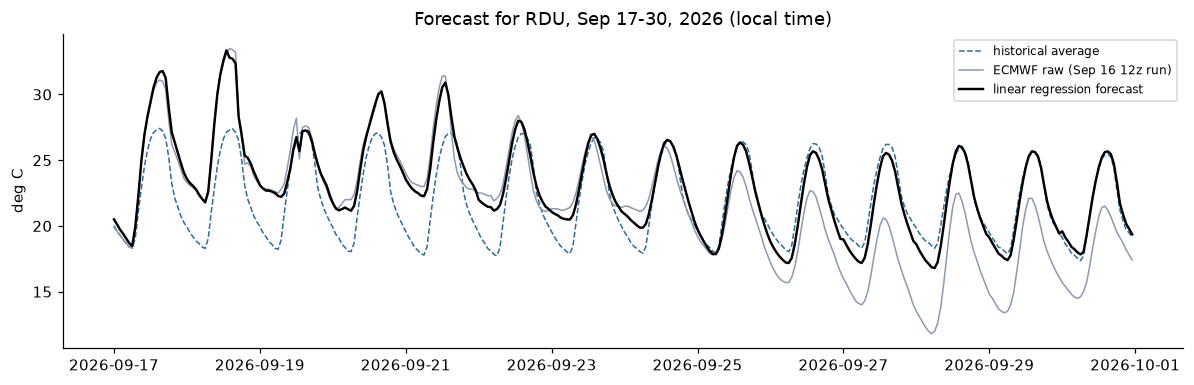

In [18]:
import hashlib

CUTOFF = pd.Timestamp("2026-09-17", tz=NY)
FINAL_RUN_DAY = pd.Timestamp("2026-09-16")
FORECAST_FILE = PROJECT_ROOT / "reports" / "forecast_2026-09-17_to_2026-09-30_linear_regression.csv"
FROZEN_FILE = PROJECT_ROOT / "scripts" / "results" / "final_forecast_M14.csv"
FROZEN_HASH = PROJECT_ROOT / "scripts" / "results" / "final_forecast_M14.sha256"

cutoff_utc = CUTOFF.tz_convert("UTC")
train_all = samples[(samples["target_utc"] < cutoff_utc) & samples["temperature"].notna()]
final = samples[samples["run_day"].eq(FINAL_RUN_DAY)].reset_index(drop=True)
final_models = fit_by_day(train_all, FINAL_FEATURES)
final["forecast"] = predict_by_day(final_models, final)
frozen = pd.read_csv(FROZEN_FILE)

checks = {
    "trained only on targets before 12am Sep 17": train_all["target_utc"].max() < cutoff_utc,
    "336 hours: 12am Sep 17 - 11pm Sep 30": len(final) == 336 and final["target_utc"].min() == cutoff_utc,
    "a forecast for every hour": final["forecast"].notna().all(),
    "frozen file unchanged (SHA-256)": hashlib.sha256(FROZEN_FILE.read_bytes()).hexdigest() == FROZEN_HASH.read_text().split()[0],
    "same forecast as the frozen file": (final["target_local"].tolist() == frozen["hour_local"].tolist()
                                         and np.allclose(final["forecast"].round(2), frozen["temperature_forecast_c"])),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())

output = pd.DataFrame({
    "hour_local": final["target_local"],            # report at hh:51 is labelled hh
    "forecast_deg_c": final["forecast"].round(2),
    "historical_average_deg_c": final["hist_avg"].round(2),
    "ecmwf_raw_deg_c": final["ecmwf_12z"].round(2),
})
FORECAST_FILE.parent.mkdir(parents=True, exist_ok=True)
output.to_csv(FORECAST_FILE, index=False)
print(f"Saved {FORECAST_FILE.relative_to(PROJECT_ROOT)} (trained on {len(train_all):,} rows)")

fig, ax = plt.subplots(figsize=(11, 3.6))
when = pd.to_datetime(output["hour_local"])
ax.plot(when, output["historical_average_deg_c"], color="#2a6f97", linestyle="--", linewidth=1, label="historical average")
ax.plot(when, output["ecmwf_raw_deg_c"], color="#8d99ae", linewidth=1, label="ECMWF raw (Sep 16 12z run)")
ax.plot(when, output["forecast_deg_c"], color="black", linewidth=1.6, label="linear regression forecast")
ax.set(title="Forecast for RDU, Sep 17-30, 2026 (local time)", ylabel="deg C")
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "final_forecast")
plt.show()

### 7.1 What the final model learned

The same two weights as in 5.4, now for the 14 models of the final forecast: how much of ECMWF's forecast departure from normal is kept on each forecast day (the rest falls back to the historical average), and how much of ECMWF's error over the last six observed hours is carried forward.

forecast day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
weight on ECMWF (both ECMWF terms),0.94,1.00,0.98,0.95,0.92,0.87,0.83,0.81,0.75,0.66,0.57,0.48,0.38,0.24
weight on the recent ECMWF error,0.33,0.21,0.17,0.13,0.15,0.09,0.11,0.13,0.14,0.06,-0.06,-0.13,-0.03,0.03


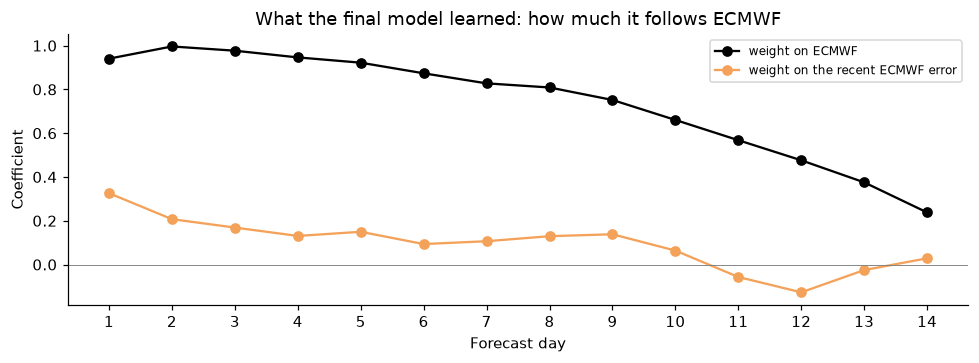

In [19]:
coefficients = pd.DataFrame({day: model.coef_ for day, model in final_models.items()}, index=FINAL_FEATURES)
trust = pd.DataFrame({
    "weight on ECMWF (both ECMWF terms)": coefficients.loc["nwp_lagged_anomaly"] + coefficients.loc["nwp_anomaly"],
    "weight on the recent ECMWF error": coefficients.loc["nwp_recent_error"],
}).T
trust.columns.name = "forecast day"
display(trust.round(2))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(trust.columns, trust.iloc[0], marker="o", color="black", label="weight on ECMWF")
ax.plot(trust.columns, trust.iloc[1], marker="o", color="#f4a259", label="weight on the recent ECMWF error")
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="What the final model learned: how much it follows ECMWF", xlabel="Forecast day", ylabel="Coefficient")
ax.set_xticks(range(1, 15))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "lr_weight_on_ecmwf")
plt.show()

### 7.2 Comparison forecasts for the test window (for `05`)

`05` only scores forecasts; it trains nothing. So every comparison method also makes its Sep 17–30 forecast here, trained on exactly the same rows as the final model (targets before 12am Sep 17) and issued from the same evening (11pm Sep 16). These comparisons were added on Oct 5, 2026; they do not change the final forecast, which is checked against the frozen file again below.

The validation scores of the same methods (Fold 1, Fold 2, and the average of the six 2026 windows) are saved next to them, so `05` can put validation and test side by side.

In [20]:
COMPARISON_FILE = PROJECT_ROOT / "reports" / "forecast_2026-09-17_to_2026-09-30_comparison_methods.csv"
VALIDATION_FILE = PROJECT_ROOT / "reports" / "validation_summary.csv"

comparison = pd.DataFrame({
    "hour_local": final["target_local"],
    "lead_day": final["lead_day"],
    "persistence": final["persistence"],
    "historical_average": final["hist_avg"],
    "lr_raw_noaa": fit_raw_lr(train_all).predict(final[RAW_X]),
    "lr_noaa_anomalies": predict_by_day(fit_by_day(train_all, NOAA_ANOMALY), final),
    "ecmwf_raw": final["ecmwf_12z"],
    "ecmwf_lagged_mean": final["ecmwf_lagged_mean"],
    "gfs_raw": final["gfs_12z"],
    "lr_temperature_target": predict_by_day(fit_by_day(train_all, TEMPERATURE_INPUTS, base=None), final, base=None),
    "lr_final": final["forecast"],
})
checks = {
    "336 hours, same hours as the frozen file": len(comparison) == 336 and comparison["hour_local"].tolist() == frozen["hour_local"].tolist(),
    "lr_final = frozen forecast": np.allclose(comparison["lr_final"].round(2), frozen["temperature_forecast_c"]),
    "every method has a forecast for every hour": comparison.notna().all().all(),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())
comparison.round(2).to_csv(COMPARISON_FILE, index=False)
print(f"Saved {COMPARISON_FILE.relative_to(PROJECT_ROOT)}")

# Validation scores of the same methods (same names as the columns above)
COLUMNS = {"Persistence": "persistence", "Historical average": "historical_average",
           "LR, raw NOAA values": "lr_raw_noaa", "LR, NOAA anomalies": "lr_noaa_anomalies",
           "ECMWF raw": "ecmwf_raw", "ECMWF lagged mean": "ecmwf_lagged_mean",
           RAW_TARGET: "lr_temperature_target", "LR, NOAA + ECMWF (final)": "lr_final"}
fold_mae = pd.concat({fold: pd.concat([mae(step1_errors[fold].drop(columns="lead_day")),
                                       mae(step3_errors[fold].drop(columns="lead_day")),
                                       mae(group_errors[fold][[RAW_TARGET]])]) for fold in FOLDS}, axis=1)
fold_mae = fold_mae[~fold_mae.index.duplicated()]
validation = pd.DataFrame({
    "fold1_mae": fold_mae["Fold 1 (2025)"], "fold2_mae": fold_mae["Fold 2 (2026)"],
    "windows_mae": window_mae["Average"],
}).reindex(list(COLUMNS))
for period in ["fold1", "fold2", "windows"]:
    validation[f"{period}_pct_vs_hist_avg"] = 100 * (1 - validation[f"{period}_mae"] / validation.loc["Historical average", f"{period}_mae"])
validation.index = validation.index.map(COLUMNS).rename("method")
validation.round(3).to_csv(VALIDATION_FILE)
print(f"Saved {VALIDATION_FILE.relative_to(PROJECT_ROOT)}")
display(validation.round(2))

,passed
"336 hours, same hours as the frozen file",True
lr_final = frozen forecast,True
every method has a forecast for every hour,True


Saved reports/forecast_2026-09-17_to_2026-09-30_comparison_methods.csv
Saved reports/validation_summary.csv


,fold1_mae,fold2_mae,windows_mae,fold1_pct_vs_hist_avg,fold2_pct_vs_hist_avg,windows_pct_vs_hist_avg
method,,,,,,
persistence,3.87,2.87,3.70,-33.61,-15.16,-51.41
historical_average,2.90,2.49,2.45,0.00,0.00,0.00
lr_raw_noaa,2.98,2.50,NaN,-2.98,-0.21,NaN
lr_noaa_anomalies,3.06,2.28,2.41,-5.72,8.53,1.59
ecmwf_raw,2.44,2.02,1.82,15.89,19.04,25.48
ecmwf_lagged_mean,2.29,1.88,1.87,21.05,24.51,23.36
lr_temperature_target,2.27,1.90,NaN,21.82,23.59,NaN
lr_final,2.20,1.78,1.85,23.92,28.68,24.41
